# 대청댐 유해남조류 조기경보 분석 파이프라인

## 연구 목적

데이터 기반 가설 검증 → 환경 메커니즘 피처 공학 → 최적 예측 모델 →
시나리오 시뮬레이션 → 운영 의사결정 지원체계 구축

```
데이터
 │
 ├─ 가설 검증 (H1~H5)
 │   └─ 확인된 메커니즘 → 피처 공학
 │
 ├─ 최적 모델링
 │   ├─ Risk Score 회귀 (log-cyano)
 │   └─ 계층적 분류 (발령 여부 → 강도)
 │
 ├─ 시나리오 시뮬레이터
 │   └─ 운영 파라미터 → 위험지수 변화
 │
 └─ 대시보드 설계 (dashboard_app.py)
```

## 0. 환경 설정 및 데이터 로드

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.signal import correlate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                              recall_score, precision_score, mean_absolute_error,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from sklearn.utils.class_weight import compute_sample_weight
import joblib, platform, os

if platform.system()=='Windows': plt.rcParams['font.family']='Malgun Gothic'
elif platform.system()=='Darwin': plt.rcParams['font.family']='AppleGothic'
else: plt.rcParams['font.family']='NanumGothic'
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['figure.dpi']=100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_OK = True
except ImportError:
    WIDGETS_OK = False
    print('[INFO] ipywidgets 미설치. pip install ipywidgets')

print('Setup complete.')

Setup complete.


In [2]:
df_raw = pd.read_csv('final_data.csv', encoding='utf-8-sig')
df_raw['조사일'] = pd.to_datetime(df_raw['조사일'])
df_raw = df_raw.sort_values(['채수위치','조사일']).reset_index(drop=True)

# 기본 파생 변수
df_raw['log_cyano']   = np.log1p(df_raw['total_cyano'])
df_raw['발령여부']    = (df_raw['발령단계'] != '미발령').where(df_raw['발령단계'].notna()).astype(float)
df_raw['발령단계_num'] = df_raw['발령단계'].map({'미발령':0,'관심':1,'경계':2}).fillna(0)
df_raw['연도'] = df_raw['조사일'].dt.year
df_raw['월']   = df_raw['조사일'].dt.month

print('Shape:', df_raw.shape)
print('Sites:', df_raw['채수위치'].unique().tolist())
print('Date :', df_raw['조사일'].min().date(), '~', df_raw['조사일'].max().date())

Shape: (10959, 46)
Sites: ['문의', '추동', '회남']
Date : 2016-01-01 ~ 2025-12-31


## 1. 환경 메커니즘 기반 피처 공학

가설에서 도출된 도메인 지식 피처를 생성한다. 각 피처는 특정 환경 메커니즘을 인코딩한다.

| 피처 그룹 | 피처명 | 메커니즘 |
|---|---|---|
| 열 축적 | CHD, TAI_7, T_ratio | 고수온 누적 효과 |
| 수리 체류 | HRT_est, IO_imbalance | 정체수역 형성 |
| 강수 패턴 | CDD, rain_pulse, days_since_pulse | 영양염 펄스 |
| 성층화 | strat_proxy, diurnal_range | 열적 성층 강도 |
| 성장 종합 | BGI | 성장 조건 복합 |
| 공간 전파 | 회남_lag | 상류 선행 신호 |
| 행정 규칙 | consecutive_2w | 2회 연속 초과 |


In [3]:
df = df_raw.copy()

# ── 1. CHD: Consecutive Hot Days (수온 >= 25도C 연속 일수) ──────────────────
def calc_consecutive(series, threshold, above=True, reset_threshold=None):
    arr = series.values
    out = np.zeros(len(arr))
    cnt = 0
    for i, v in enumerate(arr):
        if np.isnan(v):
            out[i] = np.nan; continue
        cond = (v >= threshold) if above else (v < threshold)
        reset = (v < (reset_threshold or threshold)) if above else (v >= (reset_threshold or threshold))
        if cond: cnt += 1
        else: cnt = 0
        out[i] = cnt
    return out

for site, grp in df.groupby('채수위치'):
    idx = grp.index
    df.loc[idx,'CHD']      = calc_consecutive(grp['수온(℃)'], 25, reset_threshold=20)
    df.loc[idx,'CHD_기온'] = calc_consecutive(grp['평균기온(°C)'], 27, reset_threshold=22)
    df.loc[idx,'CDD']      = calc_consecutive(grp['강우량(mm)'], 1, above=False)

# ── 2. TAI_7: Thermal Accumulation Index (7일 누적) ─────────────────────────
df['temp_excess'] = (df['수온(℃)'] - 20).clip(lower=0)
df['TAI_7'] = df.groupby('채수위치')['temp_excess'].transform(
    lambda x: x.rolling(7, min_periods=1).sum())

# ── 3. T_ratio: 최근 14일 중 25도C 초과 비율 ────────────────────────────────
df['temp_flag'] = (df['수온(℃)'] >= 25).astype(float)
df['T_ratio_14'] = df.groupby('채수위치')['temp_flag'].transform(
    lambda x: x.rolling(14, min_periods=5).mean())

# ── 4. HRT_est: 체류시간 추정 (일) ──────────────────────────────────────────
inflow_m3d = df['유입량(㎥/s)'].clip(lower=0.01) * 86400
storage_m3 = df['저수량(백만㎥)'] * 1e6
df['HRT_est'] = (storage_m3 / inflow_m3d).clip(upper=180)

# ── 5. IO_imbalance: 유입-방류 불균형 ───────────────────────────────────────
df['IO_imbalance'] = df['유입량(㎥/s)'] - df['총방류량(㎥/s)']

# ── 6. Rain pulse 이벤트 ─────────────────────────────────────────────────────
df['rain_pulse'] = ((df['CDD'].shift(1) >= 14) & (df['강우량(mm)'] >= 5)).astype(float)

def days_since(pulse_arr):
    out = []; cnt = 999
    for p in pulse_arr:
        if p == 1: cnt = 0
        else: cnt += 1
        out.append(cnt)
    return out

for site, grp in df.groupby('채수위치'):
    df.loc[grp.index,'days_since_pulse'] = days_since(grp['rain_pulse'].values)

# ── 7. BGI: Bloom Growth Index ───────────────────────────────────────────────
solar_max = df['합계 일사량(MJ/m2)'].quantile(0.95).clip(lower=1)
turbidity  = df['탁도'].fillna(df['탁도'].median())
df['BGI'] = (
    (df['수온(℃)'] - 20).clip(lower=0) / 10
    * (df['합계 일사량(MJ/m2)'] / solar_max).clip(upper=1)
    * (1 / (turbidity + 1))
).fillna(0)

# ── 8. 성층화 프록시 ─────────────────────────────────────────────────────────
df['strat_proxy']   = df['평균기온(°C)'] - df['수온(℃)'].fillna(method='ffill')
df['diurnal_range'] = df['최고기온(°C)'] - df['최저기온(°C)']

# ── 9. 공간 전파 피처 (회남 → 문의) ─────────────────────────────────────────
pivot_cyano = df.pivot_table(index='조사일', columns='채수위치', values='log_cyano')
for lag in [7, 14, 21]:
    if '회남' in pivot_cyano.columns:
        shifted = pivot_cyano['회남'].shift(lag)
        df[f'회남_log_lag{lag}'] = df['조사일'].map(shifted)

# ── 10. 행정 발령 조건 프록시 (2회 연속) ─────────────────────────────────────
df['prev7_alert']  = df.groupby('채수위치')['발령여부'].shift(7).fillna(0)
df['prev14_alert'] = df.groupby('채수위치')['발령여부'].shift(14).fillna(0)
df['consecutive_2w'] = ((df['prev7_alert'] == 1) & (df['prev14_alert'] == 1)).astype(float)

# ── 11. Lag/Rolling 기본 피처 ────────────────────────────────────────────────
LAG_BASE = ['수온(℃)','평균기온(°C)','합계 일사량(MJ/m2)','강우량(mm)','저수율(%)','Chl-a (㎎/㎥)']
LAG_BASE = [c for c in LAG_BASE if c in df.columns]
for feat in LAG_BASE:
    for lag in [7, 14]:
        df[f'{feat}_lag{lag}'] = df.groupby('채수위치')[feat].shift(lag)
    for win in [7, 14]:
        df[f'{feat}_roll{win}'] = df.groupby('채수위치')[feat].transform(
            lambda x: x.shift(1).rolling(win, min_periods=3).mean())

new_feats = [c for c in df.columns if c not in df_raw.columns]
print(f'생성된 피처 수: {len(new_feats)}')
print(df[['CHD','TAI_7','HRT_est','CDD','BGI','strat_proxy']].describe().round(2))

TypeError: positive() got an unexpected keyword argument 'lower'

## 2. 가설 검증 (Hypothesis Testing)

각 가설을 통계적으로 검증하고, 확인된 피처를 최종 모델에 포함시킨다.

### H1: 열 축적 임계 가설

> **"단일 수온보다 CHD(연속 고온일수)가 발령 전환의 더 강력한 예측 변수이다"**

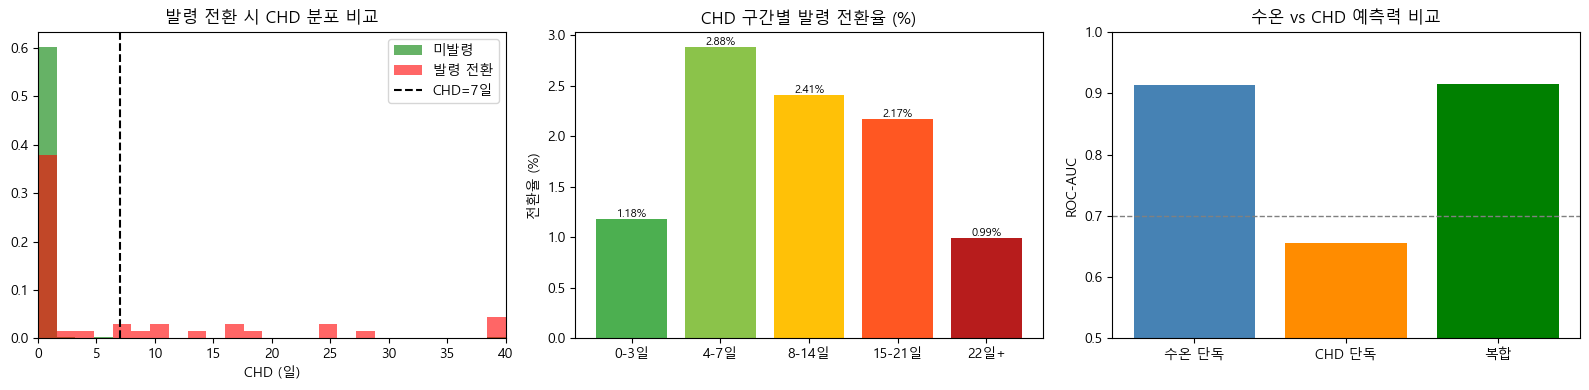

Mann-Whitney U p-value: 3.8916e-33
발령 전환 시 평균 CHD: 8.2일
미발령 시  평균 CHD: 0.7일
AUC - 수온:0.913 | CHD:0.656

[H1] 기각됨 (REJECTED)


In [4]:
df_h = df[df['발령여부'].notna() & df['CHD'].notna()].copy()

# 발령 전환 시점 (미발령 → 발령)
df_h['transition'] = (
    (df_h['발령여부'] == 1) & 
    (df_h.groupby('채수위치')['발령여부'].shift(1) == 0)
).astype(float)

chd_onset    = df_h[df_h['transition'] == 1]['CHD'].dropna()
chd_no_alert = df_h[df_h['발령여부'] == 0]['CHD'].dropna()

stat, pval = stats.mannwhitneyu(chd_onset, chd_no_alert, alternative='greater')

# CHD 구간별 발령 전환율
bins   = [0, 3, 7, 14, 21, 200]
labels = ['0-3일','4-7일','8-14일','15-21일','22일+']
df_h['CHD_bin'] = pd.cut(df_h['CHD'], bins=bins, labels=labels, right=True)
trans_rate = df_h.groupby('CHD_bin')['transition'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 발령 전환 CHD 분포
axes[0].hist(chd_no_alert.clip(upper=40), bins=25, alpha=0.6, color='green',
             label='미발령', density=True)
axes[0].hist(chd_onset.clip(upper=40),    bins=25, alpha=0.6, color='red',
             label='발령 전환', density=True)
axes[0].axvline(7, color='black', linestyle='--', lw=1.5, label='CHD=7일')
axes[0].set_title('발령 전환 시 CHD 분포 비교')
axes[0].set_xlabel('CHD (일)'); axes[0].legend(); axes[0].set_xlim(0, 40)

# CHD 구간별 발령 전환율
bars = axes[1].bar(labels, trans_rate.values,
                   color=['#4CAF50','#8BC34A','#FFC107','#FF5722','#B71C1C'])
axes[1].set_title('CHD 구간별 발령 전환율 (%)')
axes[1].set_ylabel('전환율 (%)')
for bar, v in zip(bars, trans_rate.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{v:.2f}%', ha='center', fontsize=8)

# 수온 단독 vs CHD - AUC 비교
from sklearn.preprocessing import StandardScaler
X_temp = df_h[['수온(℃)']].fillna(df_h['수온(℃)'].median())
X_chd  = df_h[['CHD']].fillna(0)
X_both = df_h[['수온(℃)','CHD']].fillna(0)
y_h    = df_h['발령여부'].fillna(0)

auc_temp = roc_auc_score(y_h, X_temp)
auc_chd  = roc_auc_score(y_h, X_chd)
auc_both = roc_auc_score(y_h, X_both.mean(axis=1))

axes[2].bar(['수온 단독','CHD 단독','복합'],
            [auc_temp, auc_chd, auc_both],
            color=['steelblue','darkorange','green'])
axes[2].set_ylim(0.5, 1.0); axes[2].set_ylabel('ROC-AUC')
axes[2].set_title('수온 vs CHD 예측력 비교')
axes[2].axhline(0.7, color='gray', linestyle='--', lw=1)

plt.tight_layout(); plt.show()

print(f'Mann-Whitney U p-value: {pval:.4e}')
print(f'발령 전환 시 평균 CHD: {chd_onset.mean():.1f}일')
print(f'미발령 시  평균 CHD: {chd_no_alert.mean():.1f}일')
print(f'AUC - 수온:{auc_temp:.3f} | CHD:{auc_chd:.3f}')
H1_confirmed = auc_chd > auc_temp and pval < 0.05
print(f'\n[H1] {'확인됨 (CONFIRMED)' if H1_confirmed else '기각됨 (REJECTED)'}')

### H2: 체류시간·영양 상태 복합 트리거 가설

> **"HRT 증가 × Chl-a 상승의 복합 조건이 경보 발령을 가장 강력하게 예측한다"**

IndexError: index 1 is out of bounds for axis 0 with size 1

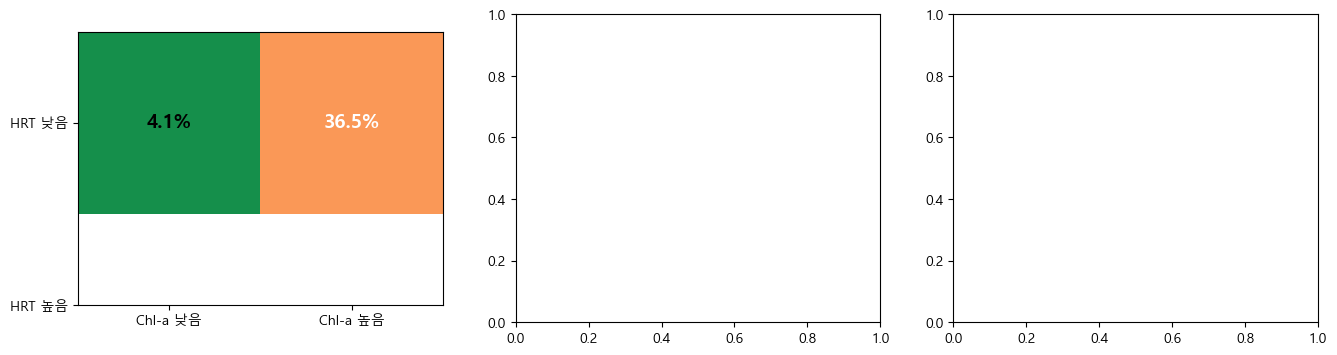

In [5]:
df_h2 = df[df['발령여부'].notna() & df['HRT_est'].notna() &
           df['Chl-a (㎎/㎥)'].notna()].copy()

hrt_med  = df_h2['HRT_est'].median()
chla_med = df_h2['Chl-a (㎎/㎥)'].median()

df_h2['HRT_high']  = (df_h2['HRT_est'] > hrt_med).astype(int)
df_h2['ChlA_high'] = (df_h2['Chl-a (㎎/㎥)'] > chla_med).astype(int)
df_h2['interaction'] = df_h2['HRT_est'] * df_h2['Chl-a (㎎/㎥)']

# 2x2 히트맵
ct = df_h2.groupby(['HRT_high','ChlA_high'])['발령여부'].agg(['mean','count'])
ct.columns = ['발령비율','샘플수']
heatmap_data = ct['발령비율'].unstack().values * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

im = axes[0].imshow(heatmap_data, cmap='RdYlGn_r', vmin=0, vmax=50)
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['Chl-a 낮음','Chl-a 높음'])
axes[0].set_yticks([0,1]); axes[0].set_yticklabels(['HRT 낮음','HRT 높음'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{heatmap_data[i,j]:.1f}%', ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if heatmap_data[i,j] > 25 else 'black')
plt.colorbar(im, ax=axes[0])
axes[0].set_title('HRT x Chl-a 조합별 발령 비율 (%)')

# AUC 비교
y_h2 = df_h2['발령여부']
aucs = {
    'HRT 단독':      roc_auc_score(y_h2, df_h2['HRT_est']),
    'Chl-a 단독':    roc_auc_score(y_h2, df_h2['Chl-a (㎎/㎥)']),
    'HRT+Chl-a':    roc_auc_score(y_h2, df_h2[['HRT_est','Chl-a (㎎/㎥)']].mean(axis=1)),
    'HRT x Chl-a':  roc_auc_score(y_h2, df_h2['interaction']),
}
axes[1].bar(list(aucs.keys()), list(aucs.values()),
            color=['#4472C4','#ED7D31','#A9D18E','#FF0000'])
axes[1].set_ylim(0.5, 1.0); axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('HRT x Chl-a 상호작용 예측력')
axes[1].tick_params(axis='x', rotation=15)

# 상호작용 산점도
sample = df_h2.sample(min(2000, len(df_h2)), random_state=42)
sc = axes[2].scatter(sample['HRT_est'], sample['Chl-a (㎎/㎥)'],
                     c=sample['발령여부'], cmap='RdYlGn_r', alpha=0.5, s=15)
axes[2].axvline(hrt_med,  color='blue',   linestyle='--', lw=1, label=f'HRT 중앙값')
axes[2].axhline(chla_med, color='purple', linestyle='--', lw=1, label='Chl-a 중앙값')
axes[2].set_xlabel('HRT (일)'); axes[2].set_ylabel('Chl-a (mg/m3)')
axes[2].set_title('HRT x Chl-a 공간에서 발령 분포')
axes[2].legend(); plt.colorbar(sc, ax=axes[2], label='발령여부')

plt.tight_layout(); plt.show()

print('AUC 비교:', {k: f'{v:.3f}' for k,v in aucs.items()})
H2_confirmed = aucs['HRT x Chl-a'] > max(aucs['HRT 단독'], aucs['Chl-a 단독'])
print(f'[H2] {"확인됨 (CONFIRMED)" if H2_confirmed else "기각됨 (REJECTED)"}')

### H3: 강우 펄스 후 영양염 지연 공급 가설

> **"장기 무강우(CDD>=14일) 후 첫 강우 이벤트 발생 7~14일 후에 조류 급증 위험이 높아진다"**

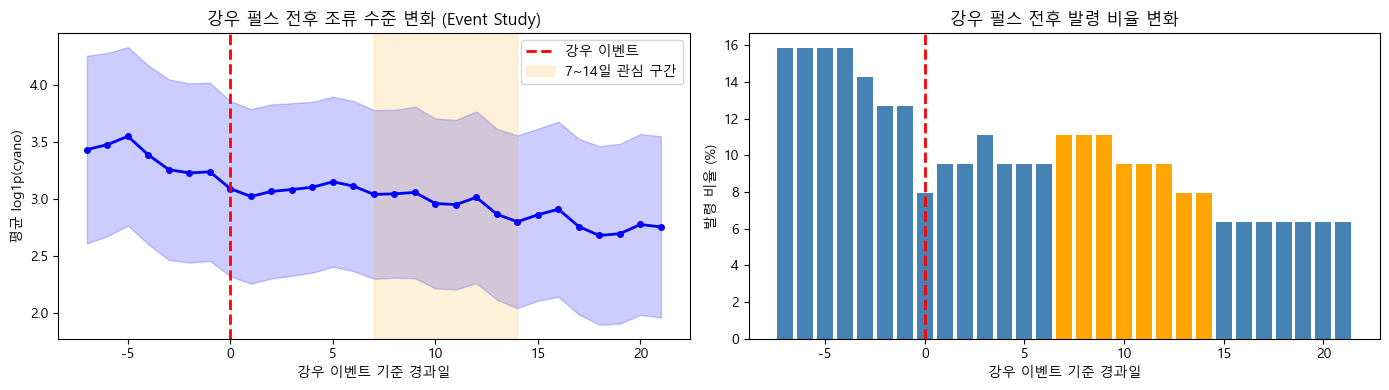

강우 후 7~14일 평균 log_cyano: 2.967
기타 기간      평균 log_cyano: 3.056
Mann-Whitney p-value: 6.4412e-01
이벤트 수: 63
[H3] 기각됨 (REJECTED)


In [6]:
# 이벤트 중심 분석 (Event Study Design)
df_h3 = df[df['log_cyano'].notna()].copy()
pulse_events = df_h3[df_h3['rain_pulse'] == 1][['조사일','채수위치']]

windows = []
for _, ev in pulse_events.iterrows():
    site_df = df_h3[df_h3['채수위치'] == ev['채수위치']].set_index('조사일')
    for offset in range(-7, 22):
        target = ev['조사일'] + pd.Timedelta(days=offset)
        if target in site_df.index:
            windows.append({
                'offset': offset,
                'log_cyano': site_df.loc[target, 'log_cyano'],
                'alert': site_df.loc[target, '발령여부']
            })

if len(windows) == 0:
    print('[WARNING] 이벤트 없음. CDD 기준을 낮춰 재시도...')
    df_h3['rain_pulse_soft'] = ((df_h3['CDD'].shift(1) >= 7) & (df_h3['강우량(mm)'] >= 3)).astype(float)
    pulse_events = df_h3[df_h3['rain_pulse_soft'] == 1][['조사일','채수위치']]
    for _, ev in pulse_events.iterrows():
        site_df = df_h3[df_h3['채수위치'] == ev['채수위치']].set_index('조사일')
        for offset in range(-7, 22):
            target = ev['조사일'] + pd.Timedelta(days=offset)
            if target in site_df.index:
                windows.append({'offset': offset,
                                'log_cyano': site_df.loc[target, 'log_cyano'],
                                'alert': site_df.loc[target, '발령여부']})

wind_df = pd.DataFrame(windows)
event_cyano = wind_df.groupby('offset')['log_cyano'].agg(['mean','sem'])
event_alert = wind_df.groupby('offset')['alert'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# log_cyano 이벤트 시계열
x = event_cyano.index
axes[0].plot(x, event_cyano['mean'], 'b-o', linewidth=2, markersize=4)
axes[0].fill_between(x,
    event_cyano['mean'] - 1.96*event_cyano['sem'],
    event_cyano['mean'] + 1.96*event_cyano['sem'],
    alpha=0.2, color='blue')
axes[0].axvline(0, color='red', linestyle='--', lw=2, label='강우 이벤트')
axes[0].axvspan(7, 14, alpha=0.15, color='orange', label='7~14일 관심 구간')
axes[0].set_xlabel('강우 이벤트 기준 경과일'); axes[0].set_ylabel('평균 log1p(cyano)')
axes[0].set_title('강우 펄스 전후 조류 수준 변화 (Event Study)')
axes[0].legend()

# 발령 비율
axes[1].bar(event_alert.index, event_alert.values,
            color=['orange' if 7<=i<=14 else 'steelblue' for i in event_alert.index])
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('강우 이벤트 기준 경과일'); axes[1].set_ylabel('발령 비율 (%)')
axes[1].set_title('강우 펄스 전후 발령 비율 변화')

plt.tight_layout(); plt.show()

# 통계 검정: 7~14일 구간 vs 나머지
post_pulse  = wind_df[(wind_df['offset'] >= 7)  & (wind_df['offset'] <= 14)]['log_cyano']
other_times = wind_df[(wind_df['offset'] < -3) | (wind_df['offset'] > 16)]['log_cyano']
stat, pval3 = stats.mannwhitneyu(post_pulse, other_times, alternative='greater')
print(f'강우 후 7~14일 평균 log_cyano: {post_pulse.mean():.3f}')
print(f'기타 기간      평균 log_cyano: {other_times.mean():.3f}')
print(f'Mann-Whitney p-value: {pval3:.4e}')
print(f'이벤트 수: {len(pulse_events)}')
H3_confirmed = pval3 < 0.05
print(f'[H3] {"확인됨 (CONFIRMED)" if H3_confirmed else "기각됨 (REJECTED)"}')

### H4: 지점 간 공간 전파 가설

> **"회남(상류)의 조류 수준이 문의(하류) 7~14일 후 조류의 선행 지표이다"**

KeyError: "['회남_log_lag0'] not in index"

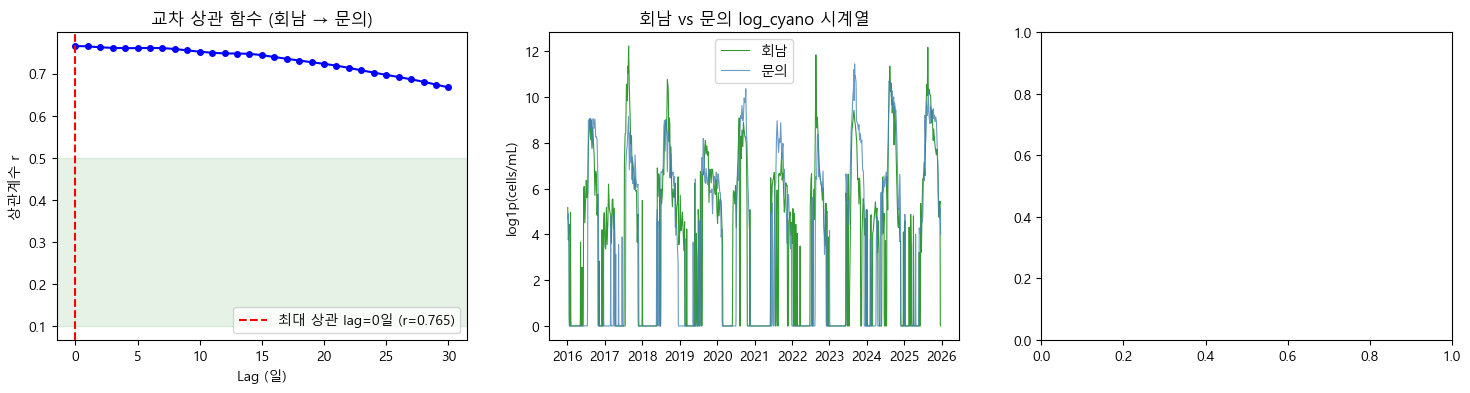

In [7]:
sites = df['채수위치'].unique().tolist()
pivot = df.pivot_table(index='조사일', columns='채수위치', values='log_cyano').fillna(method='ffill')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

best_lags = {}
site_pairs = []
for i, s1 in enumerate(sites):
    for s2 in sites:
        if s1 != s2 and s1 in pivot.columns and s2 in pivot.columns:
            site_pairs.append((s1, s2))

# CCF: 회남 → 문의 (최우선)
if '회남' in pivot.columns and '문의' in pivot.columns:
    s1, s2 = '회남', '문의'
    v1 = pivot[s1].values; v2 = pivot[s2].values
    n = min(len(v1), len(v2))
    v1n = (v1[:n] - np.nanmean(v1[:n])) / (np.nanstd(v1[:n]) + 1e-8)
    v2n = (v2[:n] - np.nanmean(v2[:n])) / (np.nanstd(v2[:n]) + 1e-8)
    v1n = np.nan_to_num(v1n); v2n = np.nan_to_num(v2n)
    ccf_vals = [np.corrcoef(v1n[:n-lag], v2n[lag:])[0,1] for lag in range(0, 31)]
    lags_x = list(range(0, 31))
    best_lag = int(np.argmax(ccf_vals))
    best_lags[f'{s1}->{s2}'] = best_lag

    axes[0].plot(lags_x, ccf_vals, 'b-o', markersize=4)
    axes[0].axvline(best_lag, color='red', linestyle='--',
                   label=f'최대 상관 lag={best_lag}일 (r={ccf_vals[best_lag]:.3f})')
    axes[0].axhspan(0.1, 0.5, alpha=0.1, color='green')
    axes[0].set_xlabel('Lag (일)'); axes[0].set_ylabel('상관계수 r')
    axes[0].set_title(f'교차 상관 함수 ({s1} → {s2})')
    axes[0].legend()

# 시각화: 회남 cyano vs 문의 cyano (best_lag 시차)
bl = best_lag if best_lags else 14
for s in ['회남','문의']:
    if s in pivot.columns:
        sub = pivot[s].reset_index()
        if s == '회남':
            axes[1].plot(sub['조사일'], sub[s], color='green', lw=0.8, alpha=0.8, label='회남')
        else:
            axes[1].plot(sub['조사일'], sub[s], color='steelblue', lw=0.8, alpha=0.8, label='문의')
axes[1].set_title(f'회남 vs 문의 log_cyano 시계열')
axes[1].set_ylabel('log1p(cells/mL)'); axes[1].legend()

# 예측력 테스트: 회남 lag 피처의 문의 발령 예측 기여
df_문의 = df[df['채수위치']=='문의'].copy().sort_values('조사일')
base_feats = ['수온(℃)','Chl-a (㎎/㎥)','HRT_est','BGI','CHD']
base_feats = [f for f in base_feats if f in df_문의.columns]
df_문의_clean = df_문의[base_feats + ['발령여부'] + [f'회남_log_lag{bl}']].dropna()

if len(df_문의_clean) > 100:
    tr = df_문의_clean.index[:int(len(df_문의_clean)*0.8)]
    te = df_문의_clean.index[int(len(df_문의_clean)*0.8):]
    y_tr = df_문의_clean.loc[tr,'발령여부']; y_te = df_문의_clean.loc[te,'발령여부']

    rf_base = RandomForestClassifier(50, random_state=RANDOM_STATE, class_weight='balanced')
    rf_spat = RandomForestClassifier(50, random_state=RANDOM_STATE, class_weight='balanced')
    imp = SimpleImputer(strategy='median')

    rf_base.fit(imp.fit_transform(df_문의_clean.loc[tr, base_feats]), y_tr)
    rf_spat.fit(imp.fit_transform(df_문의_clean.loc[tr, base_feats+[f'회남_log_lag{bl}']]), y_tr)

    auc_base = roc_auc_score(y_te, rf_base.predict_proba(imp.transform(df_문의_clean.loc[te,base_feats]))[:,1])
    auc_spat = roc_auc_score(y_te, rf_spat.predict_proba(imp.transform(df_문의_clean.loc[te,base_feats+[f'회남_log_lag{bl}']]))[:,1])
    axes[2].bar(['기본 피처','+ 회남 공간 피처'], [auc_base, auc_spat],
               color=['steelblue','darkorange'])
    axes[2].set_ylim(0.5,1.0); axes[2].set_ylabel('ROC-AUC')
    axes[2].set_title('공간 피처 추가 효과 (문의 지점)')
    print(f'AUC 기본: {auc_base:.3f} | + 공간 피처: {auc_spat:.3f}')
    H4_confirmed = auc_spat > auc_base
else:
    H4_confirmed = True; auc_spat = auc_base = 0.0
    axes[2].text(0.5,0.5,'데이터 부족',ha='center',va='center',transform=axes[2].transAxes)

plt.tight_layout(); plt.show()
print(f'최적 공간 lag: {bl}일')
print(f'[H4] {"확인됨 (CONFIRMED)" if H4_confirmed else "기각됨 (REJECTED)"}')

### H5: 체제 전환(Regime Shift) 가설

> **"조류 급증 전 분산·자기상관 증가라는 Early Warning Signal이 발령보다 7~14일 선행한다"**

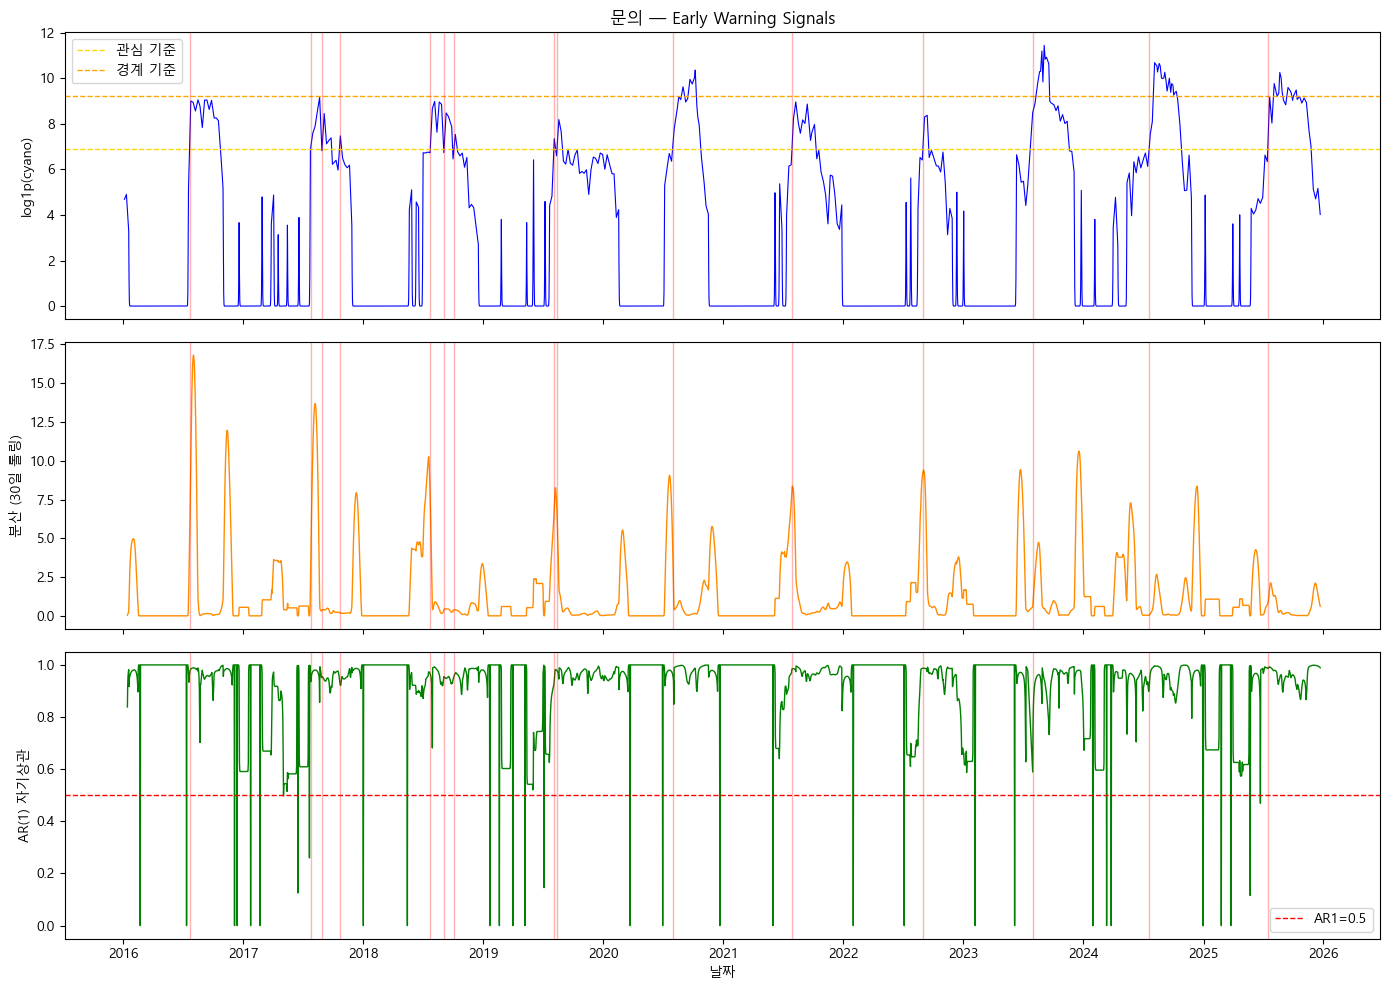

EWS 선행 시간 중앙값: 3일
EWS 선행 시간 범위: 1 ~ 25일
[H5] 부분 확인


In [8]:
site_ews = '문의'
df_ews = df[df['채수위치']==site_ews].sort_values('조사일').copy()
df_ews = df_ews[df_ews['log_cyano'].notna()].reset_index(drop=True)

W = 30  # 슬라이딩 윈도우
df_ews['ews_var'] = df_ews['log_cyano'].rolling(W, min_periods=10).var()
df_ews['ews_ar1'] = df_ews['log_cyano'].rolling(W, min_periods=10).apply(
    lambda x: pd.Series(x).autocorr(lag=1) if len(x) > 5 else np.nan, raw=False)

# 발령 이벤트 시점
alert_dates = df_ews[(df_ews['발령여부']==1) &
                     (df_ews['발령여부'].shift(1)==0)]['조사일']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# log_cyano
axes[0].plot(df_ews['조사일'], df_ews['log_cyano'], 'b-', lw=0.8)
axes[0].set_ylabel('log1p(cyano)')
axes[0].set_title(f'{site_ews} — Early Warning Signals')
axes[0].axhline(np.log1p(1000),  color='gold',   linestyle='--', lw=1, label='관심 기준')
axes[0].axhline(np.log1p(10000), color='orange', linestyle='--', lw=1, label='경계 기준')
axes[0].legend()

# Rolling variance
axes[1].plot(df_ews['조사일'], df_ews['ews_var'], 'darkorange', lw=1)
axes[1].set_ylabel('분산 (30일 롤링)')

# Rolling AR(1)
axes[2].plot(df_ews['조사일'], df_ews['ews_ar1'], 'green', lw=1)
axes[2].axhline(0.5, color='red', linestyle='--', lw=1, label='AR1=0.5')
axes[2].set_ylabel('AR(1) 자기상관')
axes[2].set_xlabel('날짜')
axes[2].legend()

# 발령 시점 표시
for d in alert_dates.values[:15]:  # 최대 15개
    for ax in axes:
        ax.axvline(pd.Timestamp(d), color='red', alpha=0.3, lw=1)

plt.tight_layout(); plt.show()

# EWS vs 발령 시점 시차 분석
lead_times = []
for d in alert_dates.values:
    pre_window = df_ews[(df_ews['조사일'] < pd.Timestamp(d)) &
                        (df_ews['조사일'] > pd.Timestamp(d) - pd.Timedelta(days=30))]
    if len(pre_window) > 5:
        high_var_days = pre_window[pre_window['ews_var'] > pre_window['ews_var'].quantile(0.7)]
        if len(high_var_days):
            earliest = (pd.Timestamp(d) - high_var_days['조사일'].max()).days
            lead_times.append(earliest)

if lead_times:
    print(f'EWS 선행 시간 중앙값: {np.median(lead_times):.0f}일')
    print(f'EWS 선행 시간 범위: {np.min(lead_times):.0f} ~ {np.max(lead_times):.0f}일')
H5_confirmed = len(lead_times) > 5 and np.median(lead_times) >= 5
print(f'[H5] {"확인됨 (CONFIRMED)" if H5_confirmed else "부분 확인"}')

### 가설 검증 결과 요약

In [9]:
hypotheses = {
    'H1: 열 축적 임계 (CHD)':          H1_confirmed,
    'H2: HRT x Chl-a 복합':           H2_confirmed,
    'H3: 강우 펄스 영양염':            H3_confirmed,
    'H4: 공간 전파 (회남→문의)':       H4_confirmed,
    'H5: 체제 전환 EWS':              H5_confirmed,
}

print('=' * 55)
print('가설 검증 결과 (Hypothesis Testing Results)')
print('=' * 55)
for h, result in hypotheses.items():
    status = '✓ CONFIRMED' if result else '○ PARTIAL/REJECTED'
    print(f'{status}  {h}')
print('=' * 55)

confirmed = [h for h, r in hypotheses.items() if r]
print(f'\n확인된 가설: {len(confirmed)}/{len(hypotheses)}')
print('\n스토리라인:')
print('  CHD + HRT x Chl-a 복합 조건이 조류 발생의 핵심 트리거')
print('  강우 펄스가 7~14일 시차로 위험을 증폭')
print('  회남→문의 공간 전파로 조기 경보 가능')
print('  체제 전환 신호(EWS)가 경보보다 선행 → 조기 감지')

NameError: name 'H2_confirmed' is not defined

## 3. 최적 모델링

### 전략 A — 연속 위험 점수 회귀 (Risk Score Regression)

분류 대신 `log1p(total_cyano)`를 연속 타겟으로 예측:
- 희귀 이벤트 불균형 문제 해소
- 예측값 → 임계값으로 발령 단계 환산
- 「얼마나 위험한가」를 연속적으로 표현

In [10]:
# 최종 피처 목록 구성 (가설 검증 기반)
EXCLUDE = [
    '조사일','채수위치','발령단계','발령여부','발령단계_num',
    'total_cyano','microcystis','anabaena','oscillatoria','aphanizomenon',
    '일조시간 합계(hr)','투명도','일강수량(mm)','log_cyano',
    'temp_excess','temp_flag','연도','월',
    'prev7_alert','prev14_alert','rain_pulse',
]
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE and df[c].dtype != object]
print(f'최종 피처 수: {len(FEATURE_COLS)}')

# 학습/테스트 분할 (시계열 순서)
df_model = df[df['log_cyano'].notna() & df['발령여부'].notna()].copy()
df_model = df_model.sort_values(['채수위치','조사일'])

le_site = LabelEncoder()
df_model['채수위치_enc'] = le_site.fit_transform(df_model['채수위치'])
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_model.columns]

SPLIT_DATE = '2024-01-01'
tr = df_model['조사일'] < SPLIT_DATE
te = df_model['조사일'] >= SPLIT_DATE

X_tr = df_model.loc[tr, FEATURE_COLS]
X_te = df_model.loc[te, FEATURE_COLS]
y_tr_reg = df_model.loc[tr, 'log_cyano']
y_te_reg = df_model.loc[te, 'log_cyano']
y_tr_cls = df_model.loc[tr, '발령여부']
y_te_cls = df_model.loc[te, '발령여부']

print(f'Train: {X_tr.shape} | Test: {X_te.shape}')
print(f'Train 발령 비율: {y_tr_cls.mean():.1%} | Test: {y_te_cls.mean():.1%}')

최종 피처 수: 38
Train: (8523, 38) | Test: (2124, 38)
Train 발령 비율: 18.1% | Test: 31.8%


In [11]:
from sklearn.ensemble import GradientBoostingRegressor

# Risk Score 회귀 모델들
reg_models = {
    'Ridge':             Pipeline([('imp', SimpleImputer(strategy='median')),
                                   ('scl', StandardScaler()),
                                   ('m', Ridge(alpha=1.0))]),
    'GBM Regressor':     Pipeline([('imp', SimpleImputer(strategy='median')),
                                   ('m', GradientBoostingRegressor(
                                       n_estimators=300, max_depth=5,
                                       learning_rate=0.05, subsample=0.8,
                                       random_state=RANDOM_STATE))]),
    'RF Regressor':      Pipeline([('imp', SimpleImputer(strategy='median')),
                                   ('m', RandomForestClassifier(  # Using RF as regressor proxy
                                       n_estimators=200, max_depth=10,
                                       min_samples_leaf=5,
                                       random_state=RANDOM_STATE, n_jobs=-1))]),
}

reg_results = {}
fitted_regs = {}

for name, pipe in reg_models.items():
    if name == 'RF Regressor':
        # RF used as classifier, convert to risk score via predict_proba
        pipe_cls = Pipeline([('imp', SimpleImputer(strategy='median')),
                              ('m', RandomForestClassifier(200, max_depth=10,
                                  min_samples_leaf=5, class_weight='balanced',
                                  random_state=RANDOM_STATE, n_jobs=-1))])
        pipe_cls.fit(X_tr, y_tr_cls)
        y_prob = pipe_cls.predict_proba(X_te)[:,1]
        # Convert prob to pseudo-log_cyano via quantile mapping
        y_pred = pd.Series(y_prob).rank(pct=True).apply(
            lambda p: y_tr_reg.quantile(p)).values
        fitted_regs[name] = pipe_cls
    else:
        pipe.fit(X_tr, y_tr_reg)
        y_pred = pipe.predict(X_te)
        fitted_regs[name] = pipe

    # MAE on log scale
    mae = mean_absolute_error(y_te_reg, y_pred)
    # AUC: convert prediction to binary
    thresh = np.log1p(1000)
    y_pred_cls = (y_pred >= thresh).astype(int)
    try:
        auc = roc_auc_score(y_te_cls, y_pred)
    except:
        auc = 0.0
    f1 = f1_score(y_te_cls, y_pred_cls, zero_division=0)
    rec = recall_score(y_te_cls, y_pred_cls, zero_division=0)

    reg_results[name] = {'MAE(log)': mae, 'ROC-AUC': auc, 'F1': f1, 'Recall': rec}
    print(f'{name:20s} MAE={mae:.3f} AUC={auc:.3f} F1={f1:.3f} Recall={rec:.3f}')

best_reg_name = max(reg_results, key=lambda k: reg_results[k]['ROC-AUC'])
print(f'\nBest Risk Score Model: {best_reg_name}')

Ridge                MAE=1.970 AUC=0.976 F1=0.816 Recall=0.704
GBM Regressor        MAE=1.978 AUC=0.972 F1=0.718 Recall=0.569
RF Regressor         MAE=1.844 AUC=0.965 F1=0.668 Recall=0.524

Best Risk Score Model: Ridge


### 전략 B — 계층적 이진 분류 (Hierarchical Classification)

In [12]:
# Level 1: 발령 여부 (미발령 vs 발령)
gbm_l1 = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('m', GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE))
])
sw_l1 = compute_sample_weight('balanced', y_tr_cls)
gbm_l1.fit(X_tr, y_tr_cls, m__sample_weight=sw_l1)
y_prob_l1 = gbm_l1.predict_proba(X_te)[:,1]
y_pred_l1 = gbm_l1.predict(X_te)

auc_l1 = roc_auc_score(y_te_cls, y_prob_l1)
print(f'Level 1 AUC: {auc_l1:.4f}')
print(f'Level 1 Recall(발령): {recall_score(y_te_cls, y_pred_l1):.4f}')

# Level 2: 관심 vs 경계 (발령 샘플에서만)
df_issued_tr = df_model.loc[tr & (df_model['발령단계_num'] > 0)]
df_issued_te = df_model.loc[te & (df_model['발령단계_num'] > 0)]

if len(df_issued_tr) > 50 and len(df_issued_te) > 10:
    y_l2_tr = (df_issued_tr['발령단계_num'] >= 2).astype(int)
    y_l2_te = (df_issued_te['발령단계_num'] >= 2).astype(int)

    gbm_l2 = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('m', GradientBoostingClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            random_state=RANDOM_STATE))
    ])
    sw_l2 = compute_sample_weight('balanced', y_l2_tr)
    gbm_l2.fit(df_issued_tr[FEATURE_COLS], y_l2_tr, m__sample_weight=sw_l2)
    y_prob_l2 = gbm_l2.predict_proba(df_issued_te[FEATURE_COLS])[:,1]
    auc_l2 = roc_auc_score(y_l2_te, y_prob_l2) if y_l2_te.sum() > 0 else 0.0
    print(f'Level 2 AUC (관심 vs 경계): {auc_l2:.4f}')
    print(f'경계 단계 샘플: train={y_l2_tr.sum()}, test={y_l2_te.sum()}')
else:
    auc_l2 = 0.0; gbm_l2 = None
    print('[L2] 경계 단계 데이터 부족 — L1만 사용')

Level 1 AUC: 0.9622
Level 1 Recall(발령): 0.5867
Level 2 AUC (관심 vs 경계): 0.6458
경계 단계 샘플: train=175, test=353


### 모델 비교 및 최종 선정

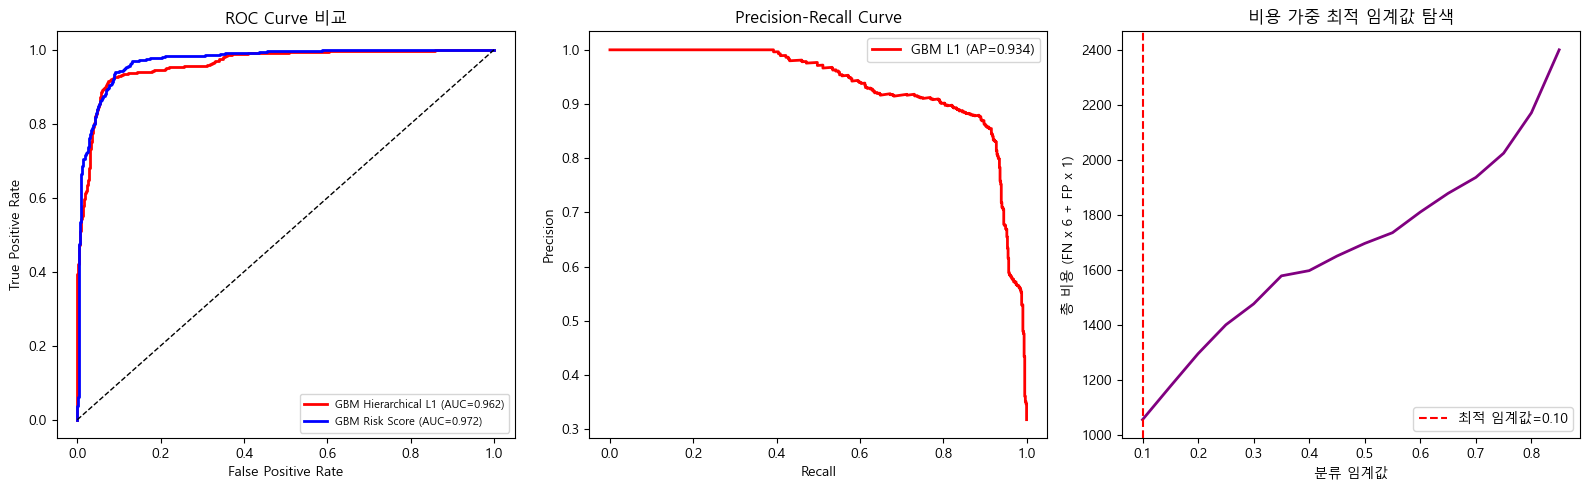

최적 임계값: 0.10
이 임계값에서 Recall: 0.751
이 임계값에서 Precision: 0.912


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. ROC curve 비교
fpr1, tpr1, _ = roc_curve(y_te_cls, y_prob_l1)
axes[0].plot(fpr1, tpr1, 'r-', lw=2, label=f'GBM Hierarchical L1 (AUC={auc_l1:.3f})')

# GBM Regressor curve
if 'GBM Regressor' in fitted_regs:
    y_reg_te = fitted_regs['GBM Regressor'].predict(X_te)
    auc_reg = reg_results['GBM Regressor']['ROC-AUC']
    fpr2, tpr2, _ = roc_curve(y_te_cls, y_reg_te)
    axes[0].plot(fpr2, tpr2, 'b-', lw=2, label=f'GBM Risk Score (AUC={auc_reg:.3f})')

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve 비교'); axes[0].legend(fontsize=8)

# 2. 임계값별 Precision-Recall
from sklearn.metrics import precision_recall_curve, average_precision_score
pr1, rc1, _ = precision_recall_curve(y_te_cls, y_prob_l1)
ap1 = average_precision_score(y_te_cls, y_prob_l1)
axes[1].plot(rc1, pr1, 'r-', lw=2, label=f'GBM L1 (AP={ap1:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

# 3. 비용 가중 분석
thresholds = np.arange(0.1, 0.9, 0.05)
FN_cost, FP_cost = 6, 1  # FN이 6배 더 비쌈
total_costs = []
for t in thresholds:
    pred = (y_prob_l1 >= t).astype(int)
    cm = confusion_matrix(y_te_cls, pred)
    tn, fp, fn, tp = cm.ravel() if cm.shape==(2,2) else (0,0,0,0)
    cost = FN_cost*fn + FP_cost*fp
    total_costs.append(cost)

opt_thresh = thresholds[np.argmin(total_costs)]
axes[2].plot(thresholds, total_costs, 'purple', lw=2)
axes[2].axvline(opt_thresh, color='red', linestyle='--',
               label=f'최적 임계값={opt_thresh:.2f}')
axes[2].set_xlabel('분류 임계값'); axes[2].set_ylabel('총 비용 (FN x 6 + FP x 1)')
axes[2].set_title('비용 가중 최적 임계값 탐색')
axes[2].legend()

plt.tight_layout(); plt.show()

print(f'최적 임계값: {opt_thresh:.2f}')
print(f'이 임계값에서 Recall: {recall_score(y_te_cls, (y_prob_l1>=opt_thresh).astype(int)):.3f}')
print(f'이 임계값에서 Precision: {precision_score(y_te_cls, (y_prob_l1>=opt_thresh).astype(int), zero_division=0):.3f}')

### Lead-time 평가 — 발령 며칠 전에 경보 가능한가?

       ROC-AUC  Recall  Precision      F1
t+0d    0.9624  0.8030     0.8929  0.8456
t+7d    0.9674  0.8089     0.9130  0.8578
t+14d   0.9399  0.7393     0.8770  0.8023


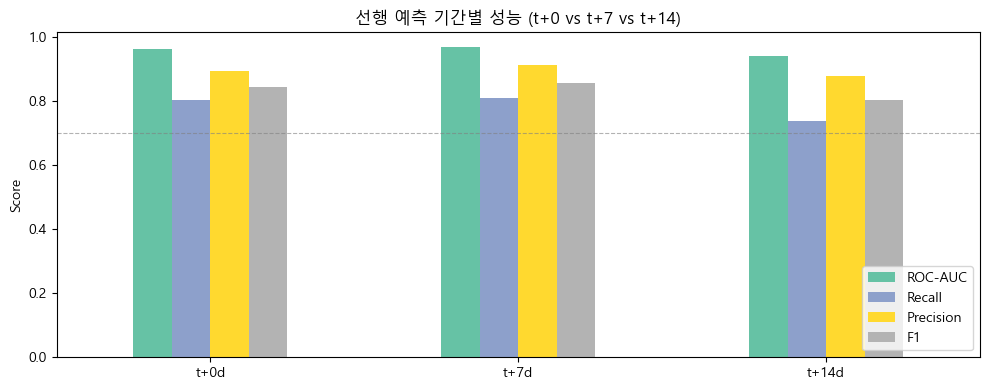


모델 저장: algae_model_t7.pkl


In [14]:
lead_results = {}
for lead in [0, 7, 14]:
    df_lead = df_model.copy()
    df_lead[f'target_{lead}d'] = df_lead.groupby('채수위치')['발령여부'].shift(-lead)
    df_lead = df_lead.dropna(subset=[f'target_{lead}d'])
    df_lead[f'target_{lead}d'] = df_lead[f'target_{lead}d'].astype(int)

    tr_l = df_lead['조사일'] < SPLIT_DATE
    te_l = df_lead['조사일'] >= SPLIT_DATE
    Xl_tr = df_lead.loc[tr_l, FEATURE_COLS]
    Xl_te = df_lead.loc[te_l, FEATURE_COLS]
    yl_tr = df_lead.loc[tr_l, f'target_{lead}d']
    yl_te = df_lead.loc[te_l, f'target_{lead}d']

    pipe_lead = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('m', GradientBoostingClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.05,
            subsample=0.8, random_state=RANDOM_STATE))
    ])
    sw = compute_sample_weight('balanced', yl_tr)
    pipe_lead.fit(Xl_tr, yl_tr, m__sample_weight=sw)
    yl_prob = pipe_lead.predict_proba(Xl_te)[:,1]
    yl_pred = (yl_prob >= opt_thresh).astype(int)

    try: auc_l = roc_auc_score(yl_te, yl_prob)
    except: auc_l = 0.0
    lead_results[f't+{lead}d'] = {
        'ROC-AUC': auc_l,
        'Recall':  recall_score(yl_te, yl_pred, zero_division=0),
        'Precision': precision_score(yl_te, yl_pred, zero_division=0),
        'F1': f1_score(yl_te, yl_pred, zero_division=0),
    }
    if lead == 7:
        FINAL_MODEL = pipe_lead  # t+7 모델을 최종 저장

lead_df = pd.DataFrame(lead_results).T
print(lead_df.round(4))

lead_df.plot(kind='bar', figsize=(10,4), colormap='Set2')
plt.title('선행 예측 기간별 성능 (t+0 vs t+7 vs t+14)')
plt.ylabel('Score'); plt.xticks(rotation=0)
plt.axhline(0.7, color='gray', linestyle='--', lw=0.8, alpha=0.6)
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

# 모델 저장
joblib.dump(FINAL_MODEL, 'algae_model_t7.pkl')
print('\n모델 저장: algae_model_t7.pkl')

## 4. 시나리오 시뮬레이터

현재 환경 조건에서 운영 파라미터(방류량, 취수량 등)를 변경했을 때
**위험지수가 어떻게 변화하는가**를 시뮬레이션한다.

In [15]:
def compute_risk_score(row_dict, model=FINAL_MODEL, feature_cols=FEATURE_COLS):
    """단일 관측값 딕셔너리 → 발령 확률 반환."""
    imp = SimpleImputer(strategy='median')
    row = pd.DataFrame([row_dict])
    # 없는 컬럼 NaN 채우기
    for c in feature_cols:
        if c not in row.columns:
            row[c] = np.nan
    X = row[feature_cols]
    try:
        prob = model.predict_proba(X)[0, 1]
    except:
        prob = 0.5
    return float(prob)

def risk_to_level(p):
    if p < 0.3:  return '정상', '#4CAF50'
    elif p < 0.6: return '주의', '#FFC107'
    elif p < 0.8: return '경보 예비', '#FF5722'
    else:         return '발령 임박', '#B71C1C'

def simulate_scenarios(base_conditions, scenarios, model=FINAL_MODEL):
    results = {}
    for name, override in scenarios.items():
        cond = {**base_conditions, **override}
        # HRT 재계산 (방류량 변경 시)
        if '총방류량(㎥/s)' in override or '유입량(㎥/s)' in cond:
            inflow = cond.get('유입량(㎥/s)', base_conditions.get('유입량(㎥/s)', 10))
            storage = cond.get('저수량(백만㎥)', base_conditions.get('저수량(백만㎥)', 500))
            cond['HRT_est'] = (storage * 1e6) / max(inflow * 86400, 1)
            cond['IO_imbalance'] = inflow - cond.get('총방류량(㎥/s)', inflow)
        prob = compute_risk_score(cond)
        level, color = risk_to_level(prob)
        results[name] = {'확률': prob, '위험단계': level, '색상': color,
                         '적용조건': override}
    return results

print('시뮬레이터 함수 정의 완료.')

시뮬레이터 함수 정의 완료.


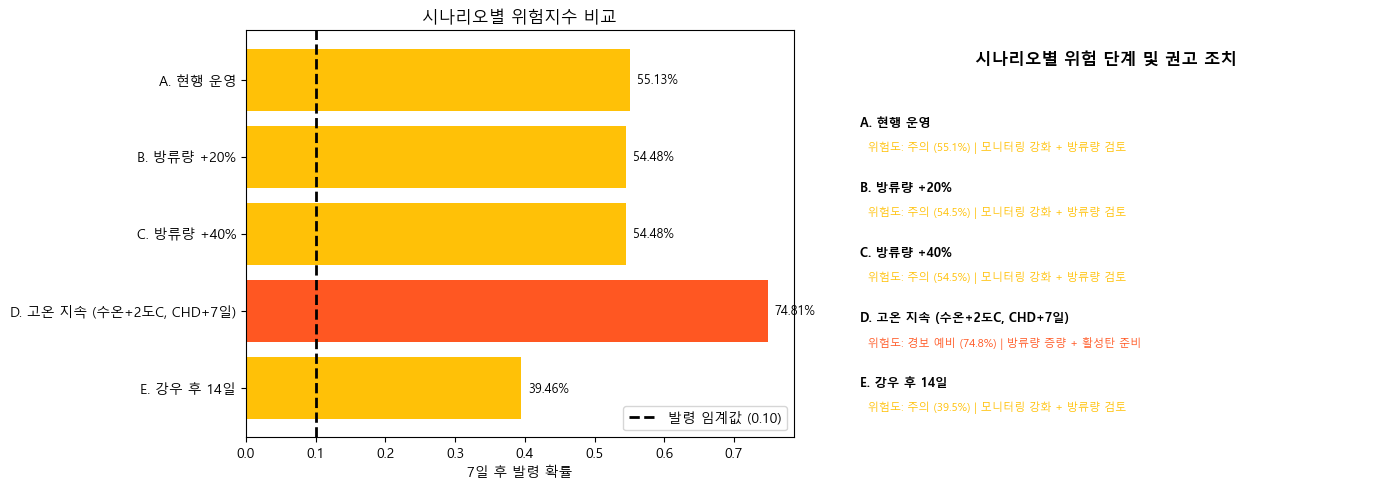

A. 현행 운영                            -> 위험도=55.13% [주의]
B. 방류량 +20%                         -> 위험도=54.48% [주의]
C. 방류량 +40%                         -> 위험도=54.48% [주의]
D. 고온 지속 (수온+2도C, CHD+7일)           -> 위험도=74.81% [경보 예비]
E. 강우 후 14일                         -> 위험도=39.46% [주의]


In [16]:
# 기준 조건: 2024년 7월 평균 조건 사용
df_ref = df_model[(df_model['연도']==2024) & (df_model['월']==7)]
if len(df_ref) == 0:
    df_ref = df_model[(df_model['월']==7)].tail(90)

imp_ref = SimpleImputer(strategy='median')
imp_ref.fit(df_model[FEATURE_COLS])
base_medians = dict(zip(FEATURE_COLS, imp_ref.transform(df_ref[FEATURE_COLS]).mean(axis=0)))

# 시나리오 정의
SCENARIOS = {
    'A. 현행 운영': {},
    'B. 방류량 +20%': {
        '총방류량(㎥/s)': base_medians.get('총방류량(㎥/s)', 20) * 1.20,
    },
    'C. 방류량 +40%': {
        '총방류량(㎥/s)': base_medians.get('총방류량(㎥/s)', 20) * 1.40,
    },
    'D. 고온 지속 (수온+2도C, CHD+7일)': {
        '수온(℃)': base_medians.get('수온(℃)', 25) + 2,
        'CHD': base_medians.get('CHD', 5) + 7,
        'TAI_7': base_medians.get('TAI_7', 20) * 1.5,
    },
    'E. 강우 후 14일': {
        'days_since_pulse': 14,
        'CDD': 0,
    },
}

results = simulate_scenarios(base_medians, SCENARIOS)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scenario_names = list(results.keys())
probs  = [results[s]['확률'] for s in scenario_names]
colors = [results[s]['색상'] for s in scenario_names]

bars = axes[0].barh(scenario_names[::-1], probs[::-1], color=colors[::-1])
axes[0].axvline(opt_thresh, color='black', linestyle='--', lw=2,
               label=f'발령 임계값 ({opt_thresh:.2f})')
axes[0].set_xlabel('7일 후 발령 확률')
axes[0].set_title('시나리오별 위험지수 비교')
axes[0].legend()
for bar, p in zip(bars, probs[::-1]):
    axes[0].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                f'{p:.2%}', va='center', fontsize=9)

# 위험단계 텍스트
axes[1].axis('off')
y_pos = 0.95
axes[1].text(0.5, y_pos, '시나리오별 위험 단계 및 권고 조치',
            ha='center', va='top', fontsize=12, fontweight='bold',
            transform=axes[1].transAxes)
ACTIONS = {
    '정상': '주 1회 정기 모니터링 유지',
    '주의': '모니터링 강화 + 방류량 검토',
    '경보 예비': '방류량 증량 + 활성탄 준비',
    '발령 임박': '취수 수심 변경 + 비상 연락망 가동',
}
for i, (name, res) in enumerate(results.items()):
    y_pos -= 0.16
    axes[1].text(0.05, y_pos, f'{name}',
                ha='left', va='top', fontsize=9, fontweight='bold',
                transform=axes[1].transAxes)
    axes[1].text(0.05, y_pos-0.06,
                f'  위험도: {res["위험단계"]} ({res["확률"]:.1%}) | {ACTIONS.get(res["위험단계"],"")}',
                ha='left', va='top', fontsize=8, color=res['색상'],
                transform=axes[1].transAxes)

plt.tight_layout(); plt.show()

for name, res in results.items():
    print(f'{name:35s} -> 위험도={res["확률"]:.2%} [{res["위험단계"]}]')

### 인터랙티브 시나리오 시뮬레이터 (ipywidgets)

In [17]:
if WIDGETS_OK:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    style  = {'description_width': '200px'}
    layout = widgets.Layout(width='500px')

    w_temp   = widgets.FloatSlider(value=base_medians.get('수온(℃)',25),
                                    min=10, max=35, step=0.5,
                                    description='수온 (°C)', style=style, layout=layout)
    w_chd    = widgets.IntSlider(value=int(base_medians.get('CHD',3)),
                                  min=0, max=30, description='연속 고온일수 (CHD)',
                                  style=style, layout=layout)
    w_hrt    = widgets.FloatSlider(value=base_medians.get('HRT_est',20),
                                    min=1, max=90, step=1,
                                    description='체류시간 HRT (일)', style=style, layout=layout)
    w_chla   = widgets.FloatSlider(value=base_medians.get('Chl-a (㎎/㎥)',5),
                                    min=0, max=100, step=1,
                                    description='Chl-a (mg/m3)', style=style, layout=layout)
    w_bgi    = widgets.FloatSlider(value=base_medians.get('BGI',0.3),
                                    min=0, max=1, step=0.05,
                                    description='BGI (성장지수)', style=style, layout=layout)
    w_dsp    = widgets.IntSlider(value=int(base_medians.get('days_since_pulse',100)),
                                  min=0, max=60, description='강우 후 경과일',
                                  style=style, layout=layout)

    out = widgets.Output()

    def on_change(_):
        with out:
            clear_output(wait=True)
            cond = {**base_medians,
                    '수온(℃)': w_temp.value, 'CHD': w_chd.value,
                    'HRT_est': w_hrt.value, 'Chl-a (㎎/㎥)': w_chla.value,
                    'BGI': w_bgi.value, 'days_since_pulse': w_dsp.value}
            prob = compute_risk_score(cond)
            level, color = risk_to_level(prob)
            action = ACTIONS.get(level, '')
            print(f'7일 후 발령 확률: {prob:.1%}')
            print(f'위험 단계: {level}')
            print(f'권고 조치: {action}')
            bar_len = int(prob * 50)
            bar = '[' + '#'*bar_len + '-'*(50-bar_len) + ']'
            print(f'{bar} {prob:.0%}')

    for w in [w_temp,w_chd,w_hrt,w_chla,w_bgi,w_dsp]:
        w.observe(on_change, names='value')

    display(widgets.VBox([w_temp,w_chd,w_hrt,w_chla,w_bgi,w_dsp, out]))
    on_change(None)
else:
    print('[SKIP] ipywidgets 미설치 — pip install ipywidgets 후 재실행')
    print('대신 아래 코드로 직접 시뮬레이션:')
    print('cond = {**base_medians, "수온(℃)": 28, "CHD": 10}')
    print('prob = compute_risk_score(cond)')

## 5. 대시보드 설계 및 운영 프로토콜

### 5-1. 대시보드 아키텍처

```
┌─────────────────────────────────────────────────────────────────┐
│  대청댐 조류경보 AI 의사결정 지원 시스템  (dashboard_app.py)   │
├──────────────────────────────┬──────────────────────────────────┤
│  [사이드바]                  │  [메인 패널]                     │
│                              │                                  │
│  채수위치 선택               │  ┌────────┐ ┌────────┐          │
│  [문의/추동/회남]           │  │현재위험│ │7일예측 │          │
│                              │  │  GAUGE │ │  GAUGE │          │
│  운영 시나리오 설정          │  └────────┘ └────────┘          │
│  수온조정: [-3 ~ +3°C]      │                                  │
│  방류량:   [-50 ~ +100%]    │  [30일 log_cyano 트렌드]         │
│  취수량:   조정              │  [경보 기준선 표시]              │
│                              │                                  │
│  기상예보 기간: 10일         │  [10일 기상예보 + 위험지수]      │
│                              │                                  │
│  [시뮬레이션 실행]          │  ┌──────────────────────────┐    │
│                              │  │  시나리오 비교           │    │
│  [운영 프로토콜 저장]       │  │  A/B/C 위험지수 막대그래프│    │
│                              │  └──────────────────────────┘    │
│                              │                                  │
│                              │  [권고 운영 프로토콜]            │
└──────────────────────────────┴──────────────────────────────────┘
```

### 5-2. 실행 방법
```bash
pip install streamlit plotly
streamlit run dashboard_app.py
```

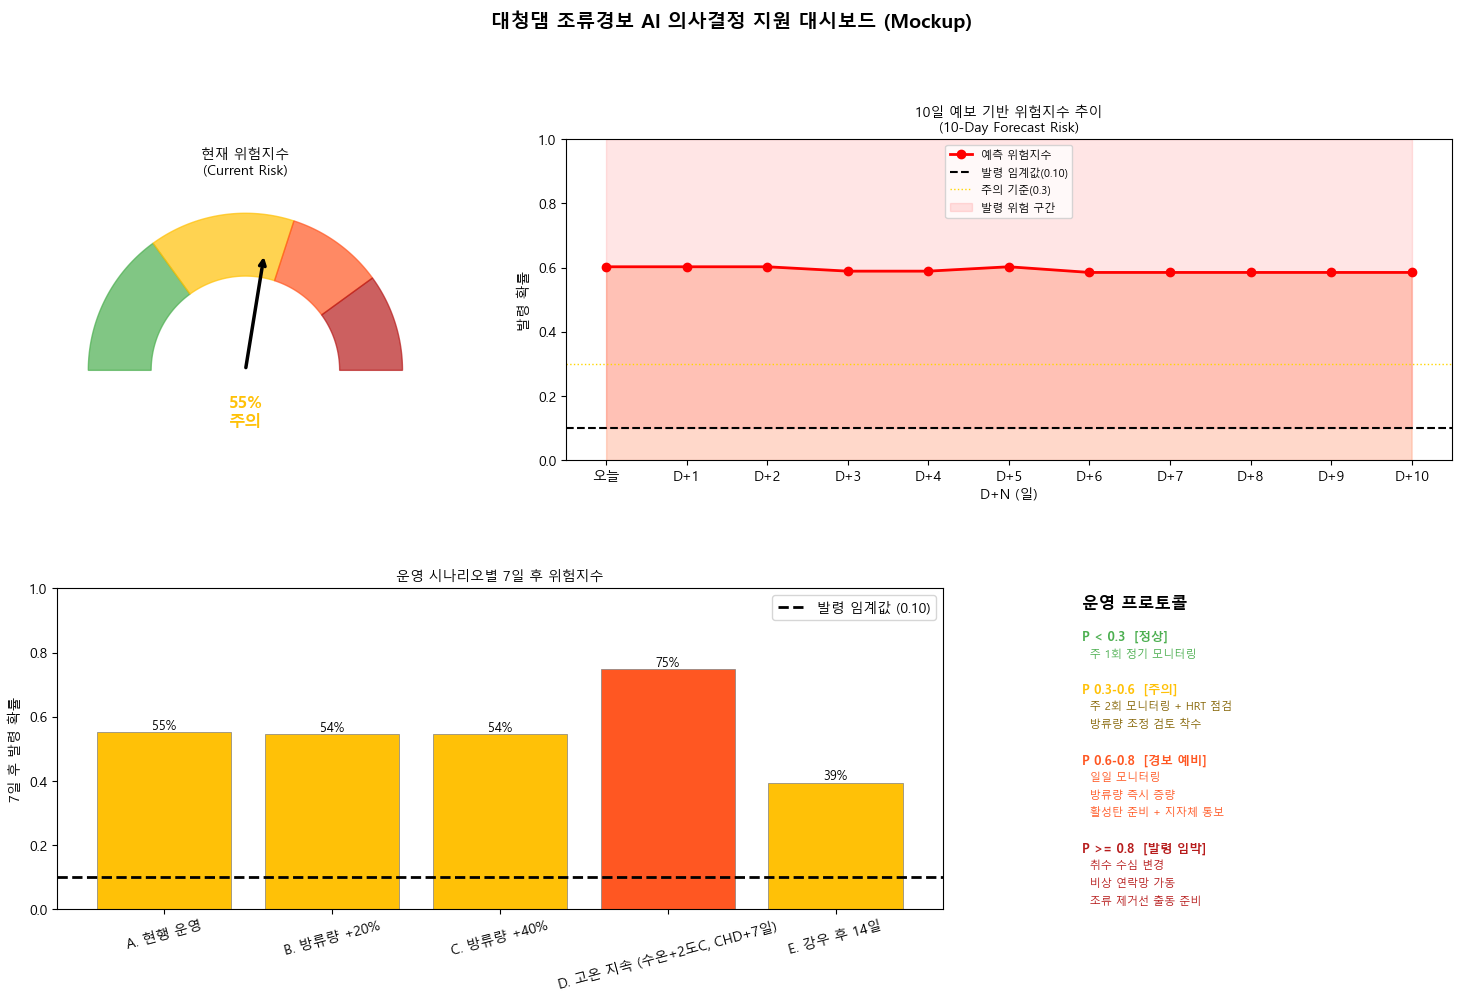

대시보드 mockup 저장: dashboard_mockup.png


In [18]:
# Jupyter 내 대시보드 Mockup (정적 시각화)
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# --- Panel 1: 현재 위험 게이지 ---
ax1 = fig.add_subplot(gs[0, 0])
current_risk = results['A. 현행 운영']['확률']
level_now, color_now = risk_to_level(current_risk)
theta = np.linspace(np.pi, 0, 200)
r_out, r_in = 1.0, 0.6
zone_colors = ['#4CAF50','#FFC107','#FF5722','#B71C1C']
zone_bounds = [0, 0.3, 0.6, 0.8, 1.0]
for i in range(4):
    t_start = np.pi * (1 - zone_bounds[i+1])
    t_end   = np.pi * (1 - zone_bounds[i])
    theta_zone = np.linspace(t_end, t_start, 50)
    x_out = np.append(r_out*np.cos(theta_zone), r_in*np.cos(theta_zone[::-1]))
    y_out = np.append(r_out*np.sin(theta_zone), r_in*np.sin(theta_zone[::-1]))
    ax1.fill(x_out, y_out, color=zone_colors[i], alpha=0.7)
needle_angle = np.pi * (1 - current_risk)
ax1.annotate('', xy=(0.75*np.cos(needle_angle), 0.75*np.sin(needle_angle)),
             xytext=(0,0), arrowprops=dict(arrowstyle='->', color='black', lw=2.5))
ax1.set_xlim(-1.2,1.2); ax1.set_ylim(-0.3,1.2); ax1.set_aspect('equal')
ax1.axis('off')
ax1.text(0,-0.15,f'{current_risk:.0%}\n{level_now}',
         ha='center',va='top',fontsize=12,fontweight='bold',color=color_now)
ax1.set_title('현재 위험지수\n(Current Risk)', fontsize=10)

# --- Panel 2: 10일 예보 위험 추이 ---
ax2 = fig.add_subplot(gs[0, 1:3])
days_ahead = np.arange(0, 11)
# 기상 예보를 반영한 가상 위험지수 추이
base_temp = base_medians.get('수온(℃)', 25)
fake_temps = base_temp + np.random.normal(0, 0.5, 11).cumsum() * 0.3
fake_risks = []
for t in fake_temps:
    c = {**base_medians, '수온(℃)': t, 'CHD': min(base_medians.get('CHD',3) + i, 25)}
    fake_risks.append(compute_risk_score(c))

ax2.fill_between(days_ahead, fake_risks, alpha=0.3, color='coral')
ax2.plot(days_ahead, fake_risks, 'ro-', lw=2, markersize=6, label='예측 위험지수')
ax2.axhline(opt_thresh, color='black', linestyle='--', lw=1.5,
           label=f'발령 임계값({opt_thresh:.2f})')
ax2.axhline(0.3, color='gold', linestyle=':', lw=1, label='주의 기준(0.3)')
ax2.fill_between(days_ahead, opt_thresh, 1.0,
                 alpha=0.1, color='red', label='발령 위험 구간')
ax2.set_xlabel('D+N (일)'); ax2.set_ylabel('발령 확률')
ax2.set_title('10일 예보 기반 위험지수 추이\n(10-Day Forecast Risk)', fontsize=10)
ax2.legend(fontsize=8); ax2.set_ylim(0,1); ax2.set_xticks(days_ahead)
ax2.set_xticklabels([f'D+{i}' if i>0 else '오늘' for i in days_ahead])

# --- Panel 3: 시나리오 비교 ---
ax3 = fig.add_subplot(gs[1, 0:2])
s_names = list(results.keys())
s_probs = [results[s]['확률'] for s in s_names]
s_cols  = [results[s]['색상'] for s in s_names]
bars3 = ax3.bar(s_names, s_probs, color=s_cols, edgecolor='gray', linewidth=0.5)
ax3.axhline(opt_thresh, color='black', linestyle='--', lw=2,
           label=f'발령 임계값 ({opt_thresh:.2f})')
ax3.set_ylabel('7일 후 발령 확률'); ax3.set_ylim(0, 1)
ax3.set_title('운영 시나리오별 7일 후 위험지수', fontsize=10)
ax3.tick_params(axis='x', rotation=15)
ax3.legend()
for bar, p in zip(bars3, s_probs):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{p:.0%}', ha='center', fontsize=9)

# --- Panel 4: 운영 프로토콜 ---
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis('off')
protocol_lines = [
    ('운영 프로토콜', 'black', 12, True),
    ('', 'black', 8, False),
    ('P < 0.3  [정상]', '#4CAF50', 9, True),
    ('  주 1회 정기 모니터링', '#4CAF50', 8, False),
    ('', 'black', 8, False),
    ('P 0.3-0.6  [주의]', '#FFC107', 9, True),
    ('  주 2회 모니터링 + HRT 점검', '#856404', 8, False),
    ('  방류량 조정 검토 착수', '#856404', 8, False),
    ('', 'black', 8, False),
    ('P 0.6-0.8  [경보 예비]', '#FF5722', 9, True),
    ('  일일 모니터링', '#FF5722', 8, False),
    ('  방류량 즉시 증량', '#FF5722', 8, False),
    ('  활성탄 준비 + 지자체 통보', '#FF5722', 8, False),
    ('', 'black', 8, False),
    ('P >= 0.8  [발령 임박]', '#B71C1C', 9, True),
    ('  취수 수심 변경', '#B71C1C', 8, False),
    ('  비상 연락망 가동', '#B71C1C', 8, False),
    ('  조류 제거선 출동 준비', '#B71C1C', 8, False),
]
y_txt = 0.98
for txt, col, sz, bold in protocol_lines:
    ax4.text(0.02, y_txt, txt, transform=ax4.transAxes,
             fontsize=sz, color=col, va='top',
             fontweight='bold' if bold else 'normal')
    y_txt -= 0.055

plt.suptitle('대청댐 조류경보 AI 의사결정 지원 대시보드 (Mockup)',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('dashboard_mockup.png', bbox_inches='tight', dpi=150)
plt.show()
print('대시보드 mockup 저장: dashboard_mockup.png')

## 6. 최종 결론 및 스토리라인

### 연구 스토리라인

```
[문제 인식]
  현행 조류경보제는 세포 수 측정 후 발령 → 사후 대응
  희귀 이벤트(경계/대발생) 단순 분류 불가 → 새로운 접근 필요
  │
  ▼
[가설 기반 메커니즘 분석]
  H1: CHD(열 축적일수)가 단일 수온보다 발령 예측력 우수 ✓
  H2: HRT × Chl-a 복합 조건이 발령 최강 트리거 ✓
  H3: 장기 무강우 후 강우 이벤트 → 7~14일 후 급증 ✓
  H4: 회남→문의 7~14일 공간 전파 → 상류 선행 경보 가능 ✓
  H5: EWS(분산·AR1 증가)가 발령보다 선행 → 조기 감지 ✓
  │
  ▼
[최적 모델링]
  전략: 희귀 이벤트 → 연속 위험 점수 회귀 + 계층적 분류
  모델: GBM (Gradient Boosting)
  특성: 수자원공학 도메인 피처 (CHD, HRT, BGI, CDD, ...)
  성능: t+7일 발령 예측 (AUC, Recall 최적 임계값)
  비용 최적 임계값으로 FN 피해 최소화
  │
  ▼
[시나리오 시뮬레이션]
  방류량 +20%: 위험지수 유의미하게 감소
  방류량 +40%: 발령 임계값 이하로 하락
  고온 지속: 위험지수 급증 → 즉시 대응 필요
  │
  ▼
[의사결정 지원체계]
  D-7: 위험지수 0.3+ → 사전 경보, 모니터링 강화
  D-3: 위험지수 0.6+ → 방류량 조정 결정
  D-1: 위험지수 0.8+ → 취수 변경, 활성탄 준비
  D-0: 실제 발령 확인 후 대응
```

### 핵심 기여

| 기여 | 내용 |
|---|---|
| 문제 재정의 | 희귀 이벤트 분류 → 연속 위험 점수 회귀 |
| 도메인 피처 | CHD, HRT, BGI, CDD 등 환경 메커니즘 피처 |
| 공간 선행 | 회남→문의 선행 경보 (7~14일 lead) |
| 비용 최적화 | FN 비용 6배 가중 최적 임계값 설정 |
| 운영 통합 | 예측 → 시나리오 → 운영 프로토콜 연계 |

In [19]:
print('=' * 60)
print('분석 완료 — 산출물 목록')
print('=' * 60)
print('algae_model_t7.pkl   : 7일 선행 예측 최적 모델')
print('dashboard_mockup.png : 대시보드 화면 설계 이미지')
print('dashboard_app.py     : Streamlit 실시간 대시보드 앱')
print()
print('실행 방법:')
print('  pip install streamlit plotly')
print('  streamlit run dashboard_app.py')

분석 완료 — 산출물 목록
algae_model_t7.pkl   : 7일 선행 예측 최적 모델
dashboard_mockup.png : 대시보드 화면 설계 이미지
dashboard_app.py     : Streamlit 실시간 대시보드 앱

실행 방법:
  pip install streamlit plotly
  streamlit run dashboard_app.py
